In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
from pathlib import Path
import logomaker
import string
import re
import glob
import matplotlib.lines as mlines

from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import adjusted_mutual_info_score as AMI
from matplotlib.patches import Patch
import nmi
from helps import *

# SuppFig2

## Data

In [ ]:
metadata=pd.DataFrame()
shapes={}
for file in sorted(glob.glob("Datasets/*/CM/*GEX_Raw.h5ad")):
    adata=sc.read_h5ad(file)
    obs=pd.DataFrame(adata.obs["CellType"])
    dataset=file.split("/")[1]
    obs["Dataset"]=dataset
    shapes[dataset]=adata.shape
    metadata=pd.concat([metadata, obs])
with open('Tables/shapes.json', 'w') as f:
	json.dump(shapes, f)
metadata.to_csv("Tables/Metadata.tsv", sep="\t")

In [ ]:
data=pd.DataFrame(columns=["Dataset","Omic","Size"])
for omic in ["Peak","ADT","mRNA","lncRNA","GEX"]:
    print(omic)
    files=sorted(glob.glob(f"Datasets/*/CM/*{omic}_Def.h5ad"))
    for file in files:
        adata=sc.read_h5ad(file)
        ds=file.split("/")[1]
        d=pd.DataFrame([ds, omic, adata.shape[1]], index=data.columns).T
        data=pd.concat([data,d])

In [ ]:
data.to_csv("Tables/Metadata_features_size.tsv", sep="\t")

## Figure

In [4]:
metadata=pd.read_csv("Tables/Metadata.tsv", sep="\t", index_col=0)
data=pd.read_csv("Tables/Metadata_features_size.tsv", sep="\t", index_col=0)
with open('Tables/shapes.json') as f:
	shapes = json.load(f)
cts={}
for ds in sorted(set(metadata["Dataset"])):
	d=metadata[metadata["Dataset"]==ds]
	cts[ds]=len(set(d["CellType"]))
mains=data[(data["Omic"]=="Peak") ^ (data["Omic"]=="ADT")][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
gexs=data[data["Omic"]=="GEX"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
mrnas=data[data["Omic"]=="mRNA"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
lncrnas=data[data["Omic"]=="lncRNA"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]

In [5]:
tot=pd.concat([pd.DataFrame.from_dict(cts, orient="index"), mains,gexs, mrnas, lncrnas], axis=1)
tot.columns=["Number of cell types","Number of peaks or surface moelecules", "Number of genes","Number of mRNAs", "Number of lncRNAs"]
tot.to_csv("Tables/SuppTable1.tsv", sep="\t")
tot

,Number of cell types,Number of peaks or surface moelecules,Number of genes,Number of mRNAs,Number of lncRNAs
BMMCCite,37,134,3782,3977,589
BMMCMultiOme,21,31667,3622,1258,486
HSPC,11,20400,5377,5553,2242
MouseSkin,23,31114,4425,5131,2648
PBMC,12,19125,4141,2792,2330
Spleen,35,209,5067,3954,798


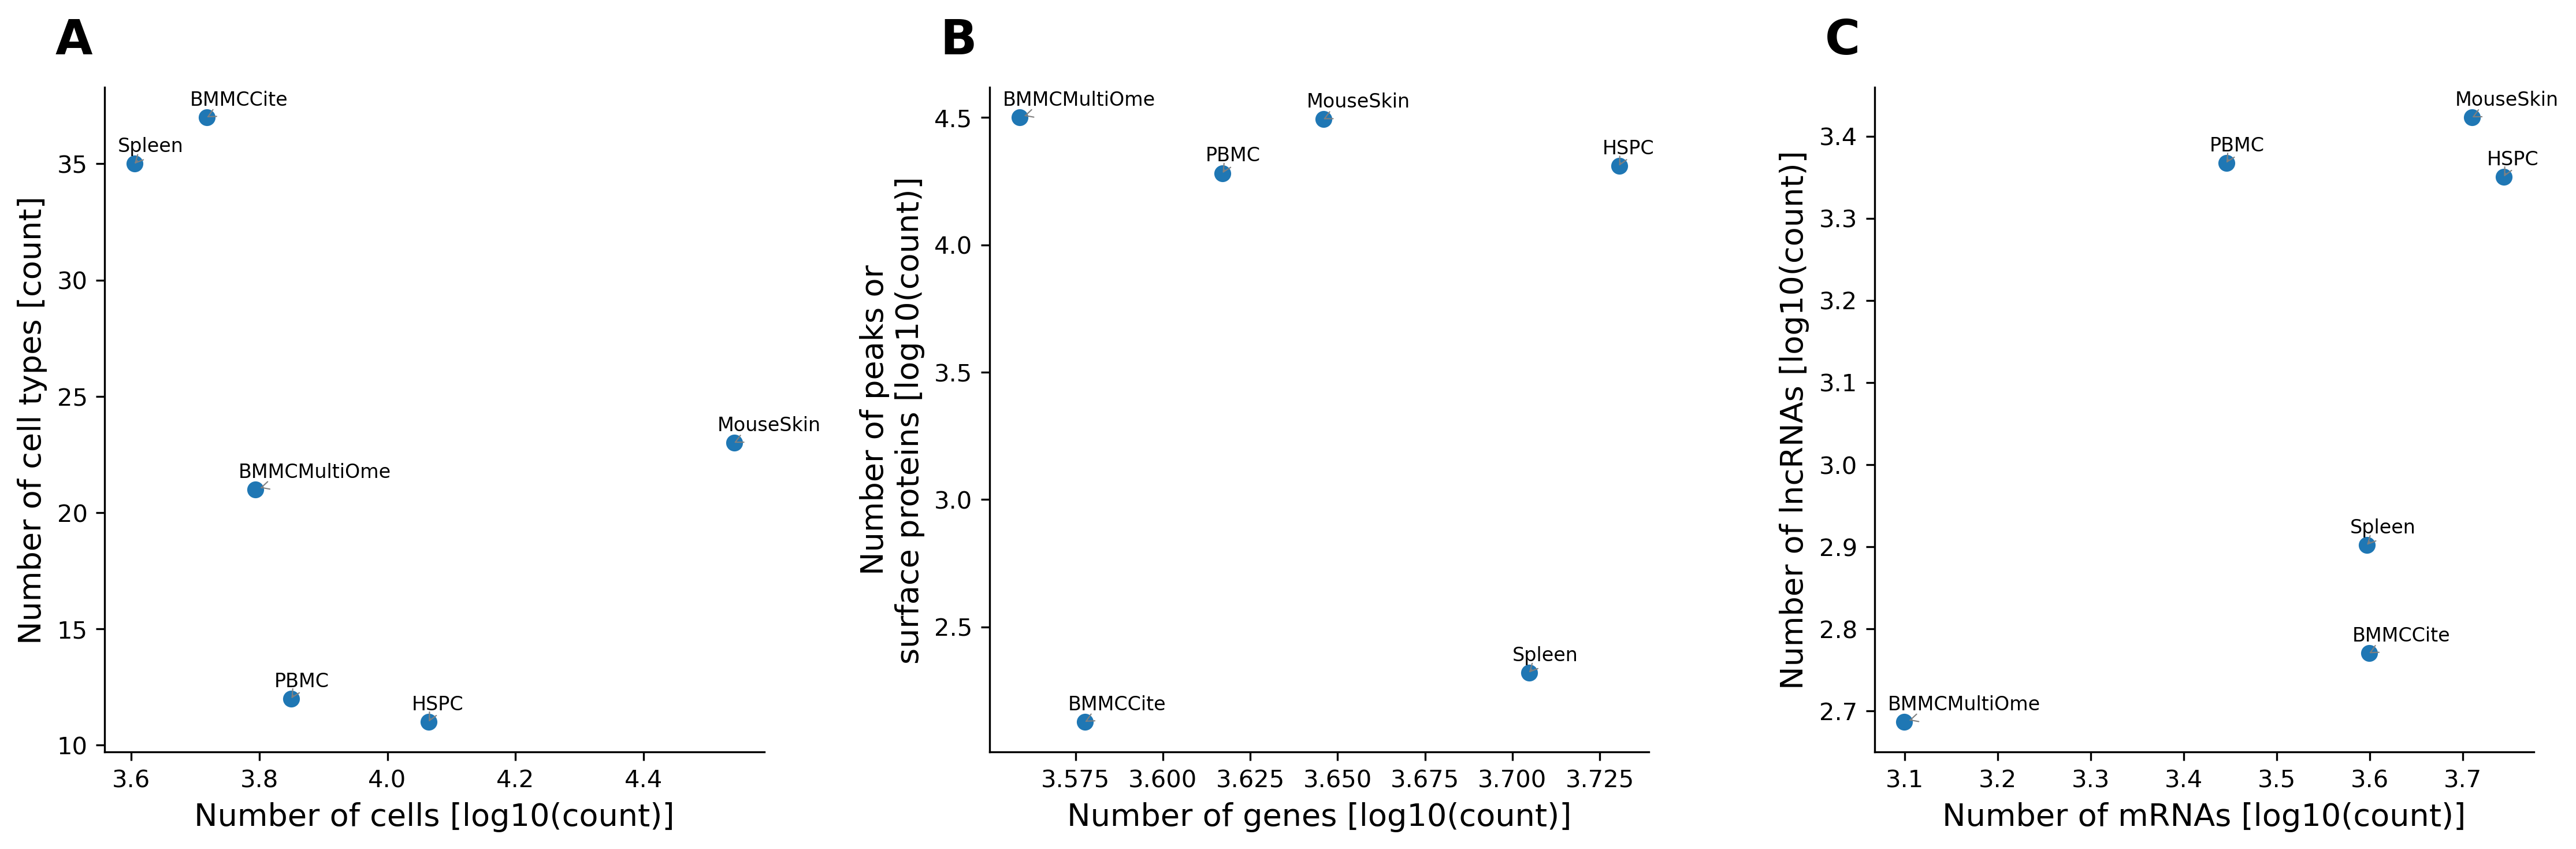

In [6]:
mains=data[(data["Omic"]=="Peak") ^ (data["Omic"]=="ADT")][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
gexs=data[data["Omic"]=="GEX"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
mrnas=data[data["Omic"]=="mRNA"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
lncrnas=data[data["Omic"]=="lncRNA"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]

fig, axs = plt.subplots(1,3, dpi=300, figsize=(15,5))
axs=axs.flatten()

x=np.log10(np.array(list(shapes.values())).T[0])
y=[cts[key] for key in shapes.keys()]
axs[0].scatter(x=x, y=y)
for i, label in enumerate(shapes.keys()):
	axs[0].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[0].set_xlabel("Number of cells [log10(count)]", size=13)
axs[0].set_ylabel("Number of cell types [count]", size=13)

x=np.log10(list(gexs.values()))
y=np.log10([mains[key] for key in gexs.keys()])
axs[1].scatter(x=x, y=y)
for i, label in enumerate(gexs.keys()):
	axs[1].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[1].set_xlabel("Number of genes [log10(count)]", size=13)
axs[1].set_ylabel("Number of peaks or\nsurface proteins [log10(count)]", size=13)

x=np.log10(list(mrnas.values()))
y=np.log10([lncrnas[key] for key in mrnas.keys()])
axs[2].scatter(x=x, y=y)
for i, label in enumerate(mrnas.keys()):
	axs[2].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[2].set_xlabel("Number of mRNAs [log10(count)]", size=13)
axs[2].set_ylabel("Number of lncRNAs [log10(count)]", size=13)

for i, ax in enumerate(axs):
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.text(-0.075, 1.05, string.ascii_uppercase[i], transform=ax.transAxes, size=20, weight='bold',rotation=0)  

plt.tight_layout(w_pad=1.5)
plt.savefig("Figures/bionSBM_SuppFig2.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig3

In [ ]:
mdata=mu.read("Datasets/PBMC/CM/PBMC_Peak_GEX_Def.h5mu")
df=pd.DataFrame(columns=["LT", "Run","NMI","NMI*","Method"])
for latent_dim in [2,6,12,18,24]:
	for run in range(0, 5):
		file_data=f"Datasets/PBMC/Mowgli/LatentDim/LT_{latent_dim}/Run{run}/MLD_Embedding.tsv.gz"
		if os.path.isfile(file_data):
			temp=pd.read_csv(file_data, index_col=0, sep="\t")
			metadata=pd.DataFrame(mdata["Peak"].obs["CellType"])
			data=pd.DataFrame([temp.columns, np.argmax(temp, axis=0).astype(str)]).T
			data.rename({0 : "cell", 1 : "cluster"}, axis=1, inplace=True)
			data.set_index("cell", inplace=True)
			inter=intersection([data.index, metadata.index])
			metadata=metadata.loc[inter]
			data=data.loc[inter]
			NMI=nmi.compute_normalised_mutual_information(metadata["CellType"], data["cluster"])
			nmi_rand=0
			for k in range(100):
				a=data["cluster"].to_list()
				np.random.shuffle(a)
				nmi_rand+=nmi.compute_normalised_mutual_information(metadata["CellType"], a)/100
			d=pd.DataFrame([latent_dim, run, NMI, nmi_rand, "Mowgli"], index=df.columns).T
			df=pd.concat([df, d])

		file_data=f"Datasets/PBMC/ShareTopic/LatentDim/LT_{latent_dim}/Run{run}/STLD_MaxTopic.tsv.gz"
		if os.path.isfile(file_data):
			data=pd.read_csv(file_data, sep="\t", index_col=0, names=["cluster"])
			metadata=pd.DataFrame(mdata["Peak"].obs["CellType"])
			inter=intersection([data.index, metadata.index])
			metadata=metadata.loc[inter]
			data=data.loc[inter]
			NMI=nmi.compute_normalised_mutual_information(metadata["CellType"], data["cluster"])
			nmi_rand=0
			for k in range(100):
				a=data["cluster"].to_list()
				np.random.shuffle(a)
				nmi_rand+=nmi.compute_normalised_mutual_information(metadata["CellType"], a)/100
			d=pd.DataFrame([latent_dim, run, NMI, nmi_rand,"ShareTopic"], index=df.columns).T
			df=pd.concat([df, d])
df["NMI/NMI*"]=(df["NMI"]/df["NMI*"]).astype(float)
df["log10(NMI/NMI*)"]=np.log10(df["NMI/NMI*"].astype(float))
df["LT"]=df["LT"].astype(int)
df["NMI"]=df["NMI"].astype(float)
df["NMI"]=df["NMI"].astype(float)
df.reset_index().drop("index", axis=1, inplace=True)
df.to_csv("Tables/NMI_vs_LatentDim.tsv.gz", sep="\t", compression="gzip")

## Figure

In [7]:
df=pd.read_csv("Tables/NMI_vs_LatentDim.tsv.gz", sep="\t", index_col=0)
df.head()

,LT,Run,NMI,NMI*,Method,NMI/NMI*,log10(NMI/NMI*)
0,2,0,0.476295,0.000749,Mowgli,635.817501,2.803332
0,2,0,0.463778,0.000706,ShareTopic,657.147554,2.817663
0,2,1,0.476295,0.000664,Mowgli,717.644568,2.855909
0,2,1,0.417286,0.000668,ShareTopic,625.078206,2.795934
0,2,2,0.476295,0.000705,Mowgli,675.713906,2.829763


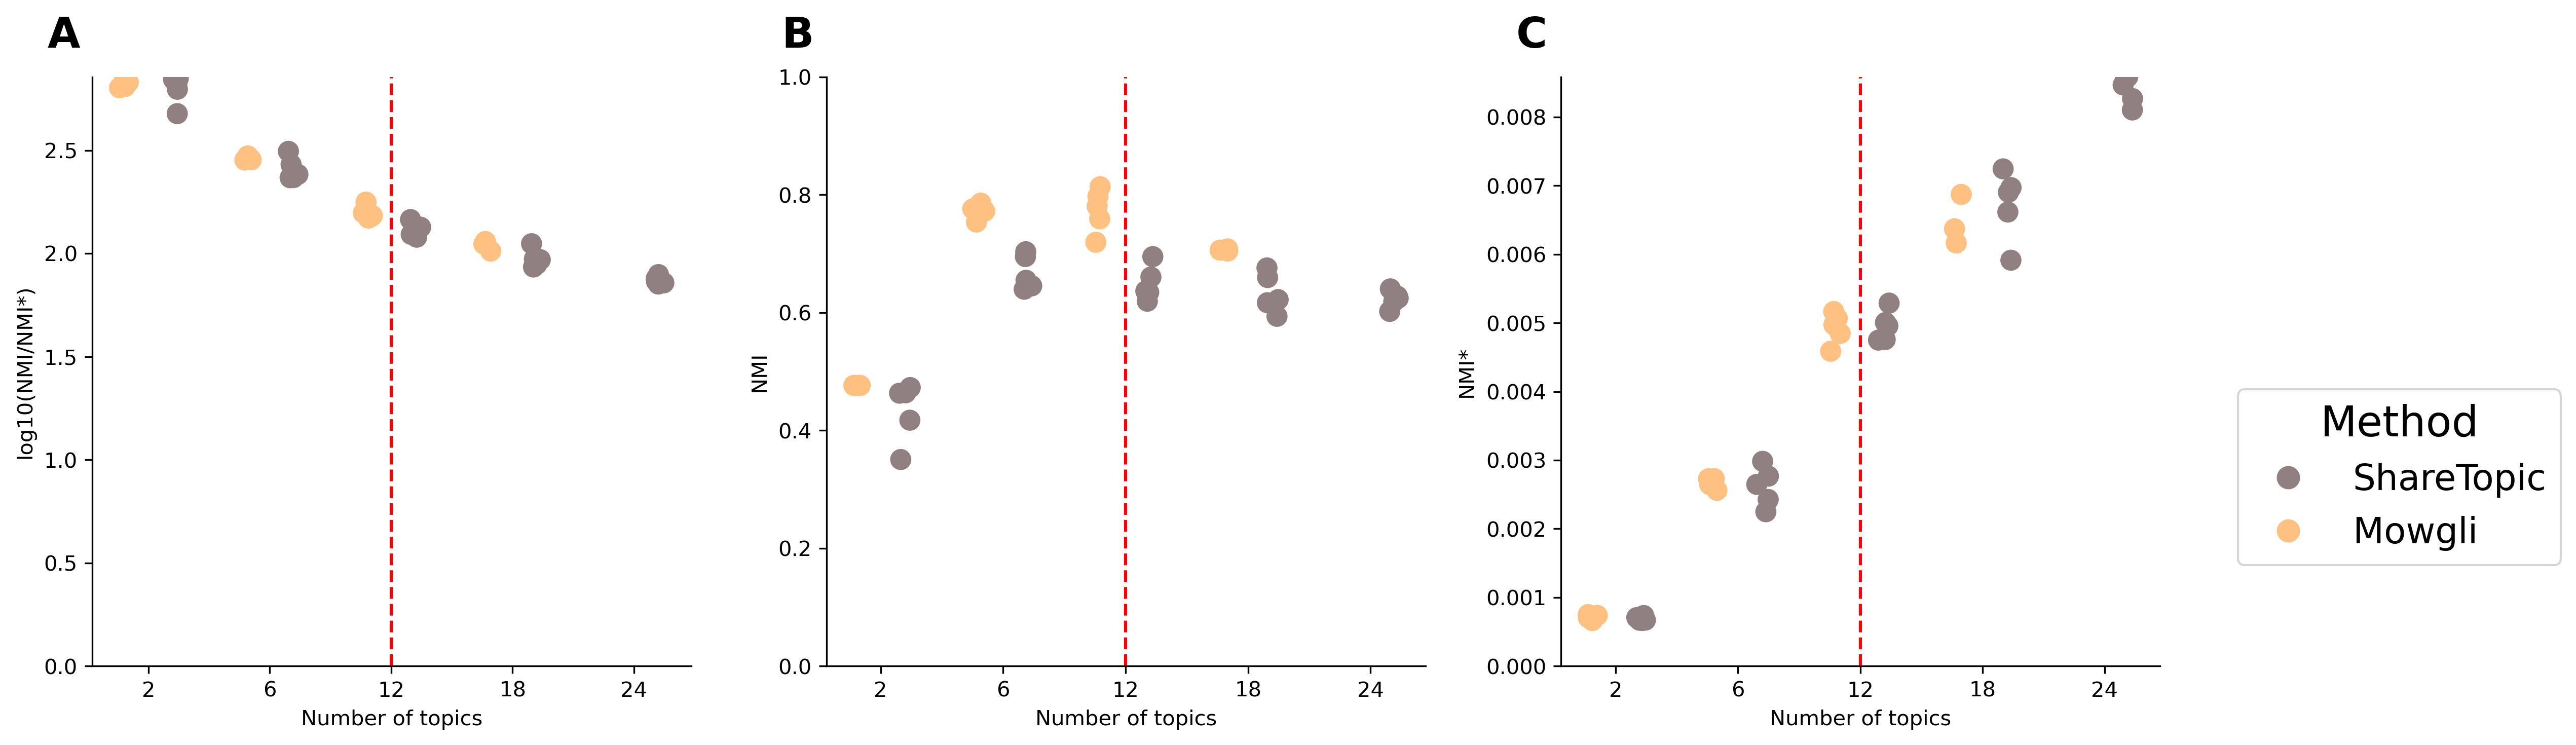

In [8]:
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli"])}
fig, axs = plt.subplots(1,3, figsize=(17,5), dpi=300)
axs=axs.flatten()
sns.stripplot(data=df, x="LT", y="log10(NMI/NMI*)", ax=axs[0], hue="Method", palette=palette, dodge=True, size=10)
sns.stripplot(data=df, x="LT", y="NMI", ax=axs[1], hue="Method", palette=palette, dodge=True, size=10)
sns.stripplot(data=df, x="LT", y="NMI*", ax=axs[2], hue="Method", palette=palette, dodge=True, size=10)
for ax in axs:
	ax.legend().remove()

for l, label in enumerate(["log10(NMI/NMI*)","NMI", "NMI*"]):
	mymax = 1 if label == "NMI" else np.max(df[label])
	axs[l].set_ylim([0, mymax])
	axs[l].vlines(x="12", ymin=0, ymax=mymax, color='red', zorder=1, linestyle="--")
	axs[l].spines['top'].set_visible(False)
	axs[l].spines['right'].set_visible(False)  
	axs[l].spines['bottom'].set_visible(True)
	axs[l].spines['left'].set_visible(True)  
	axs[l].set_xlabel("Number of topics")
	axs[l].text(-0.075, 1.05, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  
axs[1].set_ylim([0,1])
handles=[]
for key in palette.keys():
	handles.append(mlines.Line2D([], [], color=palette[key], marker='o', linestyle='None', markersize=10, label=key))
axs[2].legend(handles=handles, bbox_to_anchor=(1.7, 0.5), title="Method", fontsize=17, title_fontsize=20)

plt.tight_layout(w_pad=1.5)
plt.savefig("Figures/bionSBM_SuppFig3.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig1

In [9]:
nsb=pd.read_csv("Tables/Time_bionSBM_vs_nSBM_cells.tsv", sep="\t")
bio=pd.read_csv("Tables/Time_bionSBM_cells.tsv", sep="\t")
mow=pd.read_csv("Tables/Time_Mowgli_cells.tsv", sep="\t")
share=pd.read_csv("Tables/Time_ShareTopic_cells.tsv", sep="\t")
biobio=pd.read_csv("Tables/Time_bionSBM_cells.tsv", sep="\t")

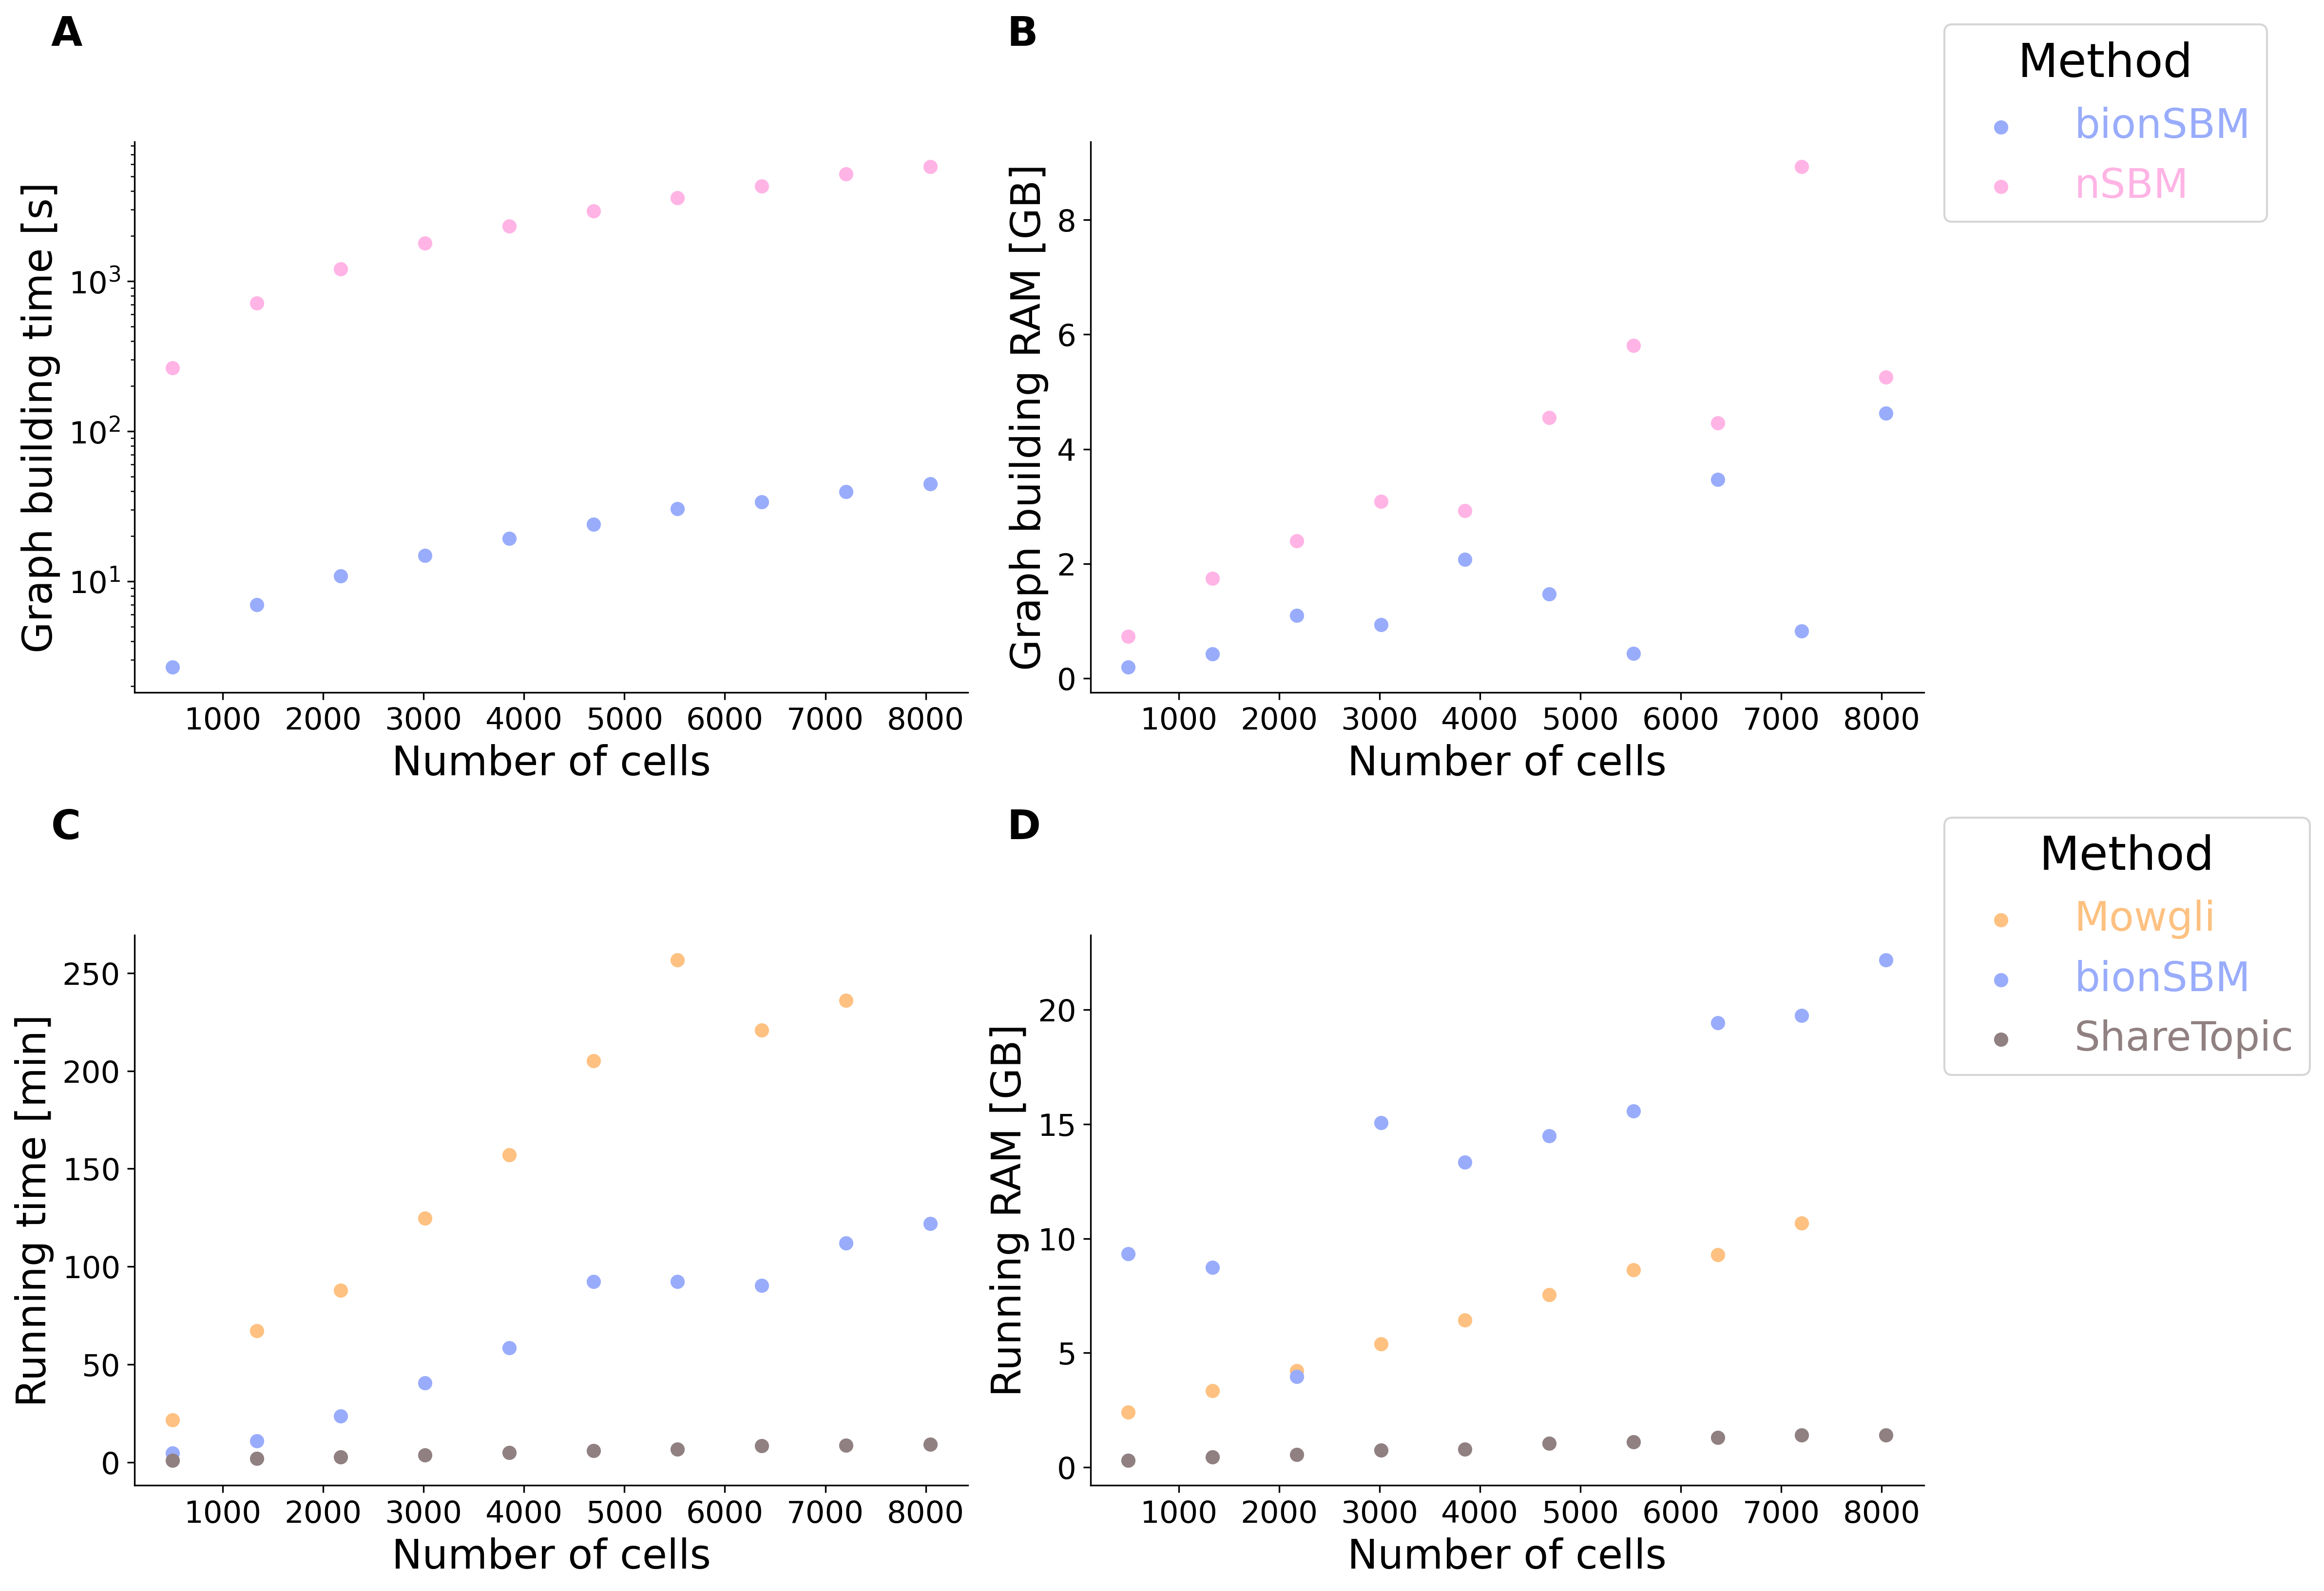

In [10]:
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli","bionSBM","nSBM"])}
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 11]}
plt.rcParams.update(params)

fig, axs = plt.subplots(2,2)
axs=axs.flatten()

axs[0].scatter(x=nsb["n_cells"], y=nsb["t_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[0].scatter(x=nsb["n_cells"], y=nsb["t_nsbm"], label="nSBM", color=palette["nSBM"])
axs[0].set_yscale("log")
axs[0].set_ylabel("Graph building time [s]")

axs[1].scatter(x=nsb["n_cells"], y=nsb["ram_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[1].scatter(x=nsb["n_cells"], y=nsb["ram_nsbm"], label="nSBM", color=palette["nSBM"])
axs[1].set_ylabel("Graph building RAM [GB]")
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles, labels, bbox_to_anchor=(1, 1.25), title="Method", 
              fontsize=20, title_fontsize=23, labelcolor=[palette[key] for key in labels]) 


axs[2].scatter(x=mow["n_cells"], y=mow["t_mowgli"]/60, label="Mowgli", color=palette["Mowgli"])
axs[2].scatter(x=bio["n_cells"], y=bio["t_bionsbm"]/60, label="bionSBM", color=palette["bionSBM"])
axs[2].scatter(x=share["n_cells"], y=share["t_sharetopic"]/60, label="ShareTopic", color=palette["ShareTopic"])
axs[2].set_ylabel("Running time [min]")

axs[3].scatter(x=mow["n_cells"], y=mow["ram_mowgli"], label="Mowgli", color=palette["Mowgli"])
axs[3].scatter(x=bio["n_cells"], y=bio["ram_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[3].scatter(x=share["n_cells"], y=share["ram_sharetopic"], label="ShareTopic", color=palette["ShareTopic"])
axs[3].set_ylabel("Running RAM [GB]")
handles, labels = axs[3].get_legend_handles_labels()
axs[3].legend(handles, labels, bbox_to_anchor=(1, 1.25), title="Method", 
              fontsize=
              20, title_fontsize=23, labelcolor=[palette[key] for key in labels]) 

for l, ax in enumerate(axs):
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_xlabel("Number of cells")
    axs[l].text(-0.1, 1.175, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  

plt.tight_layout()
plt.savefig("Figures/bionSBM_SuppFig1.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig6

In [2]:
metrics_main={}
for dataset in ["PBMC","HSPC","MouseSkin","BMMCMultiOme","BMMCCite","Spleen"]:
    main_fs = "Peak" if dataset not in ["BMMCCite", "Spleen"] else "ADT"
    file=f"Datasets/{dataset}/bionSBM/DominantTopicStability_top3_cosine_{main_fs}.tsv"
    if os.path.isfile(file):
        d=pd.read_csv(file, index_col=0, sep="\t")
        d.index=d.index.str.replace("_","+")
        d.columns=d.columns.str.replace("_","+")
        metrics_main[dataset]=d

metrics_mrna={}
for dataset in ["PBMC","HSPC","MouseSkin","BMMCMultiOme","BMMCCite","Spleen"]:
    file=f"Datasets/{dataset}/bionSBM/DominantTopicStability_top3_cosine_mRNA.tsv"
    if os.path.isfile(file):
        d=pd.read_csv(file, index_col=0, sep="\t")
        d.index=d.index.str.replace("_","+")
        d.columns=d.columns.str.replace("_","+")
        metrics_mrna[dataset]=d

In [ ]:
sns.set(style="ticks")
sns.set_style("white")

params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [23, 16]}
plt.rcParams.update(params)
fig, axs = plt.subplots(4,3)
axs=axs.flatten()

for l, dataset in enumerate(["Spleen","PBMC","HSPC","BMMCCite","MouseSkin","BMMCMultiOme"]):
    if dataset in metrics_main.keys():
        bar=True if l in [2,5] else False
        if dataset in ["BMMCCite", "Spleen"]:
            order=["ADT", "ADT+GEX", "ADT+mRNA", "ADT+lncRNA", "ADT+mRNA+lncRNA"]
        else:
            order=["Peaks", "Peaks+GEX", "Peaks+mRNAs", "Peaks+lncRNAs", "Peaks+mRNAs+lncRNAs"]
        sns.heatmap(metrics_main[dataset], annot=True, cbar_kws={"label" : "cosine similarity"}, annot_kws={"size": 30},  
                    ax=axs[l], cbar=bar, vmin=0, vmax=1, fmt='.2f')
      #  yticks=["\n".join(a.split("+")) for a in order]
       # axs[l].set_yticks(axs[l].get_yticks(), yticks, size=20)
        #axs[l].set_xticks(axs[l].get_xticks(), yticks, rotation=45, size=20)
        axs[l].spines['top'].set_visible(False)
        axs[l].spines['right'].set_visible(False)  
        axs[l].spines['bottom'].set_visible(True)
        axs[l].spines['left'].set_visible(True)  
        axs[l].text(-0.075, 1.075, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  
    else:
        continue
        
for l, dataset in enumerate(["Spleen","PBMC","HSPC","BMMCCite","MouseSkin","BMMCMultiOme"]):
    axs[l].set_title(dataset, y=1.05)


for l, dataset in enumerate(["Spleen","PBMC","HSPC","BMMCCite","MouseSkin","BMMCMultiOme"]):
    l=l+6
    if dataset in metrics_mrna.keys():
        bar=True if l in [8,11] else False
        if dataset in ["BMMCCite", "Spleen"]:
            order=["mRNA", "ADTs+mRNAs", "mRNA+lncRNAs", "ADTs+mRNAs+lncRNAs"]
        else:
            order=["mRNA", "Peaks+mRNAs", "mRNA+lncRNAs", "Peaks+mRNAs+lncRNAs"]
        mask = np.triu(np.ones_like(metrics_mrna[dataset], dtype=bool), k=1)
        sns.heatmap(metrics_mrna[dataset], annot=True, cbar_kws={"label" : "cosine similarity"}, annot_kws={"size": 34},  
                    ax=axs[l], cbar=bar, vmin=0, vmax=1, fmt='.2f', mask=mask)
      #  yticks=["\n".join(a.split("+")) for a in order]
       # axs[l].set_yticks(axs[l].get_yticks(), yticks, size=20)
        #axs[l].set_xticks(axs[l].get_xticks(), yticks, rotation=45, size=20)
        axs[l].spines['top'].set_visible(False)
        axs[l].spines['right'].set_visible(False)  
        axs[l].spines['bottom'].set_visible(True)
        axs[l].spines['left'].set_visible(True)  
        axs[l].text(-0.075, 1.075, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  
    else:
        continue
            
for l, dataset in enumerate(["Spleen","PBMC","HSPC","BMMCCite","MouseSkin","BMMCMultiOme"]):
    axs[l+6].set_title(dataset, y=1.05)


fig.tight_layout(h_pad=2, w_pad=6)
plt.savefig("Figures/bionSBM_SuppFig6.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig 4

In [5]:
validation_df = pd.DataFrame([
    ["PBMC", "B_naive", "Topic 10", "Topic 6", "PAX5", 22, 0, "Top on both", 156, "Datasets/PBMC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run22/Topic_6/knownResults.html"],   
    ["BMMCMultiOme", "Proerythroblast", "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3", 10, 'Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA_lncRNA/Run19/Topic_10/knownResults.html'],                              
    ["BMMCMultiOme", "Normoblast", "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3", 10, 'Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA_lncRNA/Run19/Topic_10/knownResults.html']],                              
    columns=["Dataset", "CellType", "mRNA-Topic", "Peak-topic", "Gene in mRNA-Topic", "Run", "Level", "Note", "Motif_Number", "Motif_HTML"])
validation_df

,Dataset,CellType,mRNA-Topic,Peak-topic,Gene in mRNA-Topic,Run,Level,Note,Motif_Number,Motif_HTML
0,PBMC,B_naive,Topic 10,Topic 6,PAX5,22,0,Top on both,156,Datasets/PBMC/bionSBM/Motifs/Peak_mRNA_lncRNA/...
1,BMMCMultiOme,Proerythroblast,Topic 7,Topic 10,KLF1,19,3,Top in all 3,10,Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA...
2,BMMCMultiOme,Normoblast,Topic 7,Topic 10,KLF1,19,3,Top in all 3,10,Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA...


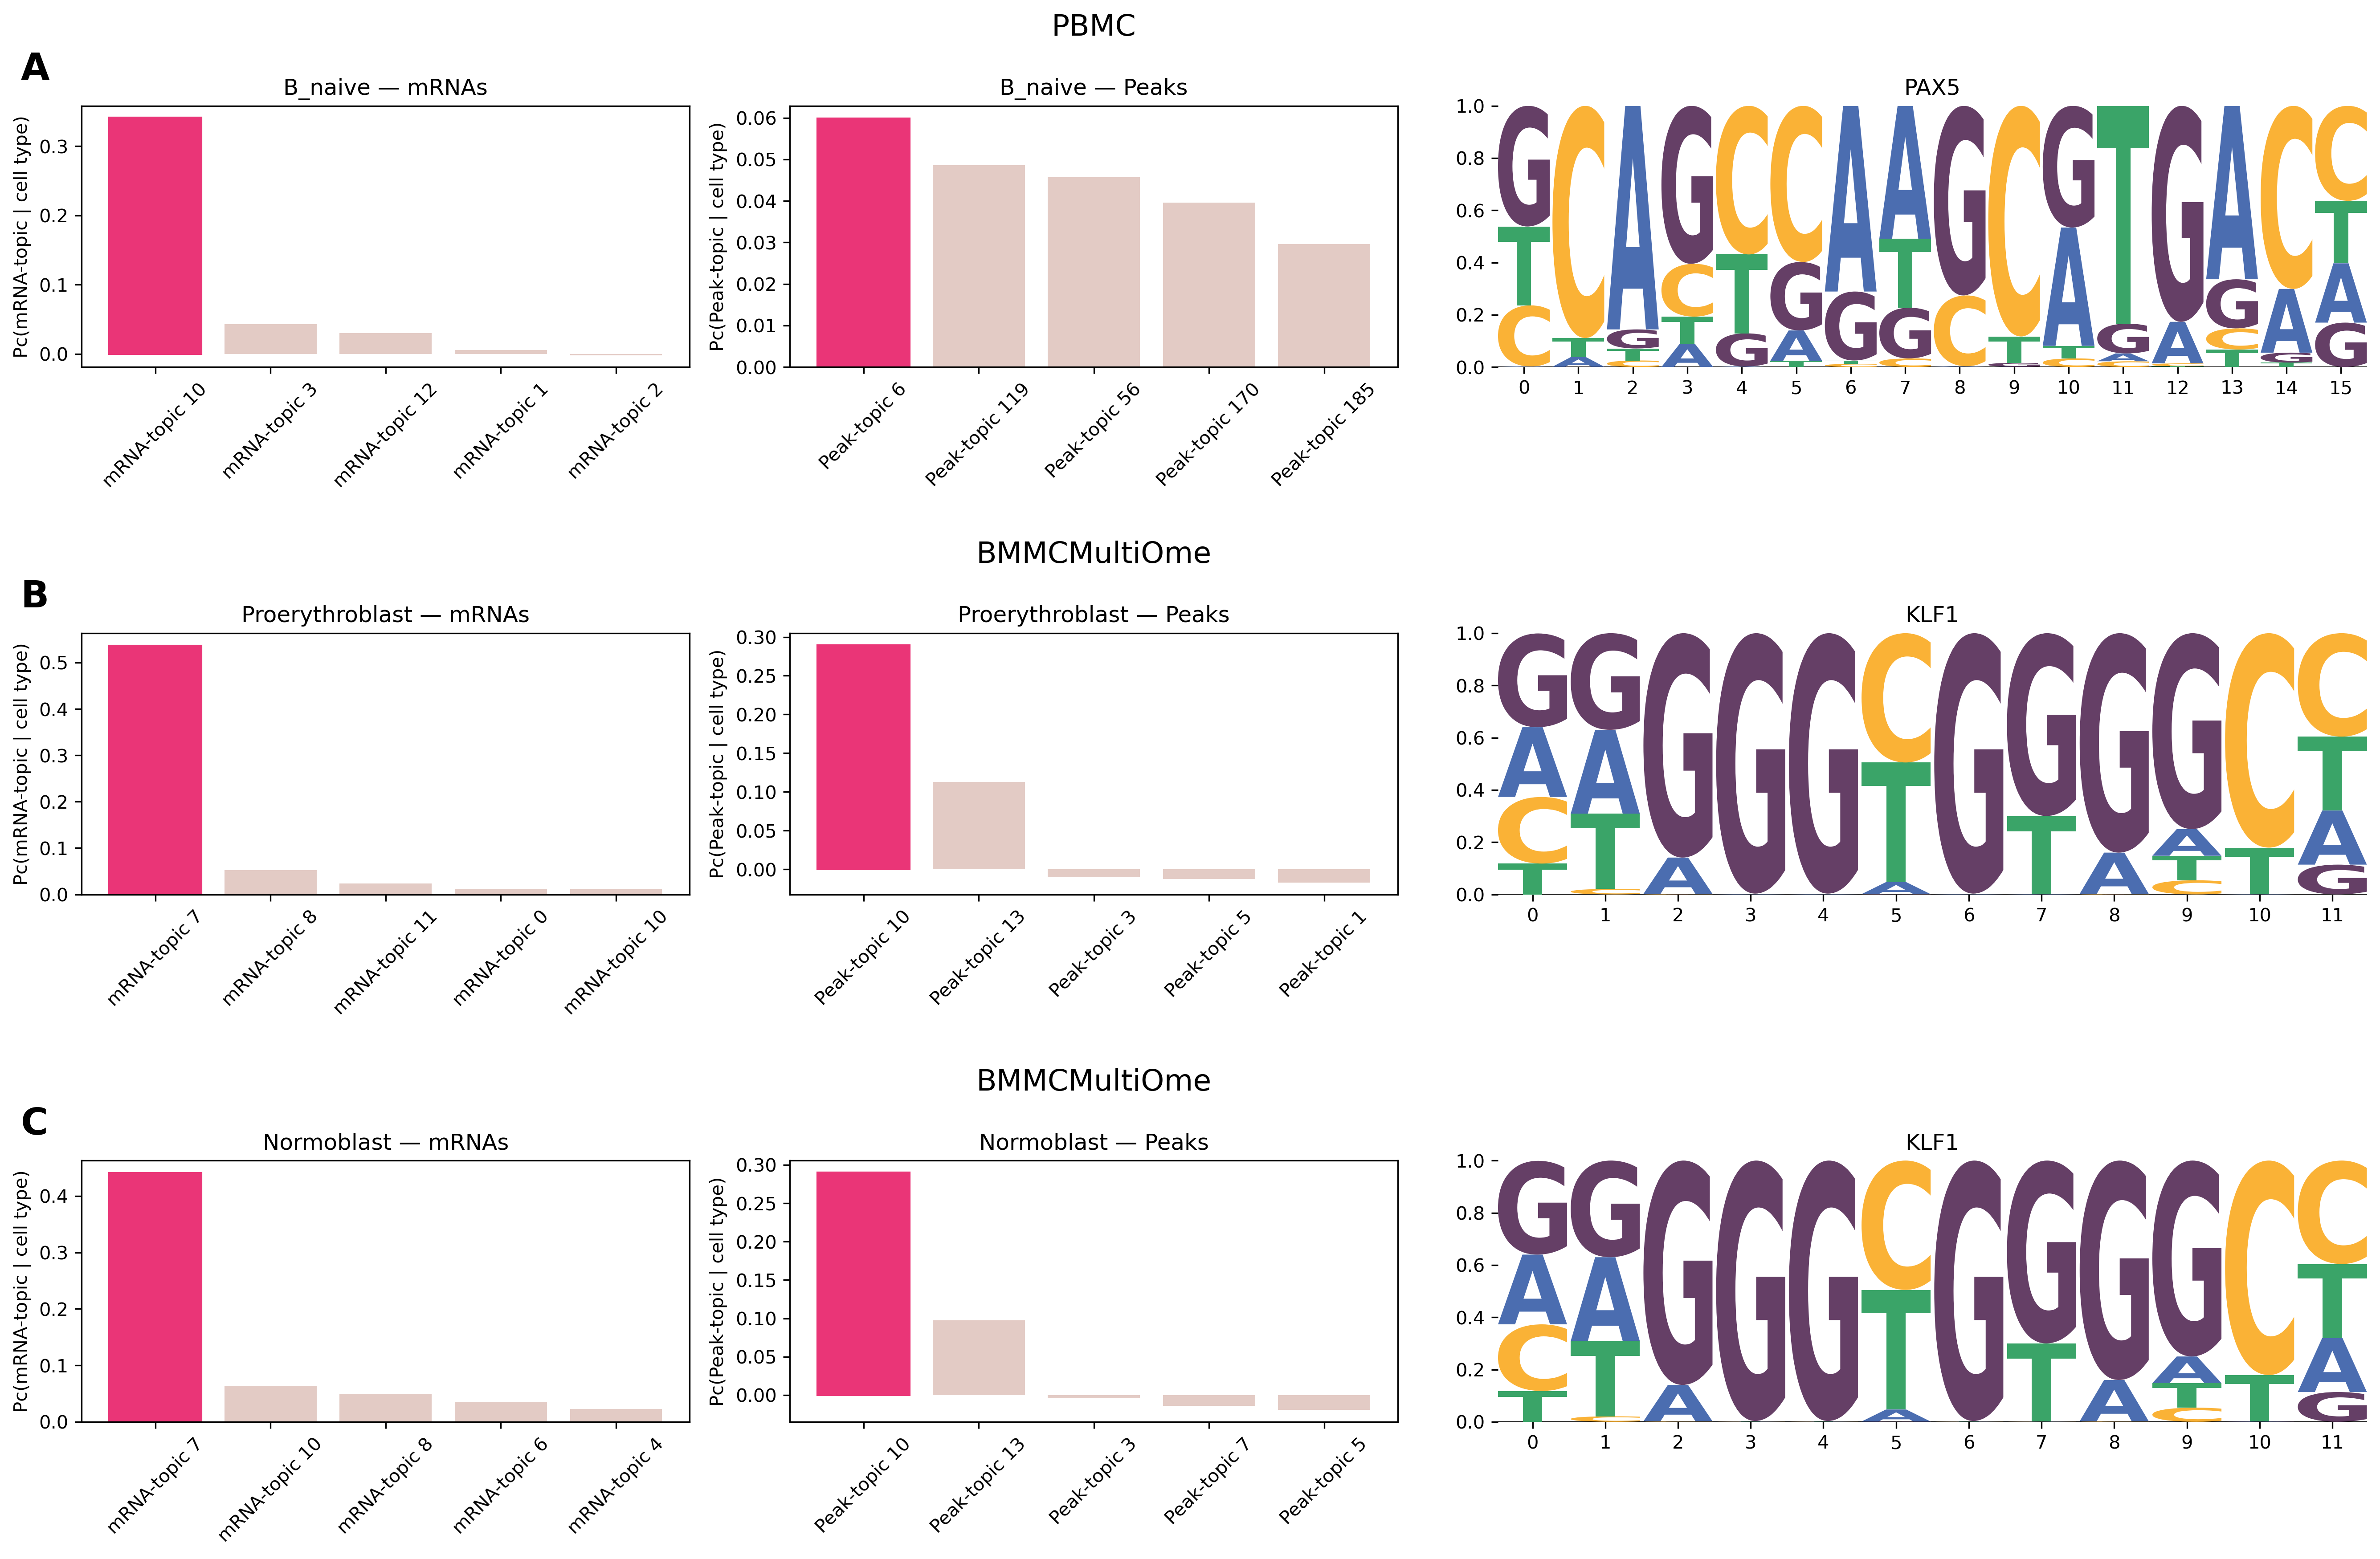

In [6]:
dna_colors = {
    "A": colors_to_use[19],
    "C": colors_to_use[14],
    "G": colors_to_use[2],
    "T": colors_to_use[5]
}

BASE_COLOR = colors_to_use[11]
HIGHLIGHT_COLOR = colors_to_use[16]

top_n = 5
# ---------------------------------------------
# Create single 3x3 figure
# ---------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12), dpi=300, gridspec_kw={"width_ratios": [0.7, 0.7, 1]})

for i, (_, row) in enumerate(validation_df.iterrows()):

    dataset = row["Dataset"]
    run = int(row["Run"])
    level = int(row["Level"])

    mrna_topic_num = int(re.search(r"\d+", row["mRNA-Topic"]).group())
    peak_topic_num = int(re.search(r"\d+", row["Peak-topic"]).group())

    cell_type_to_plot = row["CellType"]

    # ---------------------------------------------
    # Load data (same logic as your function)
    # ---------------------------------------------
    metadata = pd.read_csv(
        f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz",
        sep="\t",
        index_col=0
    )

    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"

    mRNA_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_mRNA_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    Peak_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_Peak_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    # Normalize topic naming
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")

    # Align cells
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )

    metadata = metadata.loc[common_cells]
    mRNA_topics = mRNA_topics.loc[common_cells]
    Peak_topics = Peak_topics.loc[common_cells]

    # Center matrices (same as your logic)
    mRNA_centered = mRNA_topics - mRNA_topics.mean(axis=0)
    Peak_centered = Peak_topics - Peak_topics.mean(axis=0)

    # ---------------------------------------------
    # Compute enrichment for selected celltypes
    # ---------------------------------------------
    mask_ct = metadata["CellType"].isin([cell_type_to_plot])

    mrna_enrichment = mRNA_centered.loc[mask_ct].mean(axis=0)
    peak_enrichment = Peak_centered.loc[mask_ct].mean(axis=0)

    # Validated topic names
    mrna_topic_name = [
        c for c in mRNA_topics.columns
        if c.endswith(f"_{mrna_topic_num}")
    ][0]

    peak_topic_name = [
        c for c in Peak_topics.columns
        if c.endswith(f"_{peak_topic_num}")
    ][0]

    # Top N topics
    mrna_top = mrna_enrichment.sort_values(ascending=False).head(top_n)
    peak_top = peak_enrichment.sort_values(ascending=False).head(top_n)

    # ---------------------------------------------
    # Column 1 — mRNA
    # ---------------------------------------------
    ax_m = axes[i, 0]
    bars = ax_m.bar(range(len(mrna_top)), mrna_top.values, color=BASE_COLOR)

    if mrna_topic_name in mrna_top.index:
        idx = list(mrna_top.index).index(mrna_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_m.set_xticks(range(len(mrna_top)))
    ax_m.set_xticklabels(mrna_top.index.str.replace("A_t","A-t").str.replace("_"," "), rotation=45)
    ax_m.set_title(f"{cell_type_to_plot} — mRNAs")
    ax_m.set_ylabel("Pc(mRNA-topic | cell type)")
    ax_m.text(-0.1, 1.1, string.ascii_uppercase[i], transform=ax_m.transAxes, fontsize=20, fontweight='bold')

    # ---------------------------------------------
    # Column 2 — Peak
    # ---------------------------------------------
    ax_p = axes[i, 1]
    bars = ax_p.bar(range(len(peak_top)), peak_top.values, color=BASE_COLOR)

    if peak_topic_name in peak_top.index:
        idx = list(peak_top.index).index(peak_topic_name)
        bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_p.set_xticks(range(len(peak_top)))
    ax_p.set_xticklabels(peak_top.index.str.replace("k_t","k-t").str.replace("_"," "), rotation=45)
    ax_p.set_title(f"{cell_type_to_plot} — Peaks")
    ax_p.set_ylabel("Pc(Peak-topic | cell type)")
    ax_p.text(0.5, 1.3, dataset, transform=ax_p.transAxes, fontsize=16, ha="center", va="center")

    # ---------------------------------------------
    # Column 3 — Motif Logo
    # ---------------------------------------------
    motif_number = row["Motif_Number"]
    if isinstance(motif_number, list):
        motif_number = motif_number[0]

    motif_path = (
        Path(f"Datasets/{dataset}/bionSBM/Motifs/"
             f"Peak_mRNA_lncRNA/Run{run}/"
             f"Topic_{peak_topic_num}/knownResults")
        / f"known{motif_number}.motif"
    )

    motif_df = pd.read_csv(motif_path, sep="\t", header=None, names=["A", "C", "G", "T"],skiprows=1)

    ax_logo = axes[i, 2]
    logo = logomaker.Logo(motif_df,ax=ax_logo,color_scheme=dna_colors)

    logo.style_spines(visible=False)
    logo.style_xticks(fmt='%d', anchor=0)

    ax_logo.set_title(row["Gene in mRNA-Topic"])
    ax_logo.set_ylabel("")

plt.tight_layout()
plt.savefig(f"Figures/bionSBM_SuppFig4.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig5

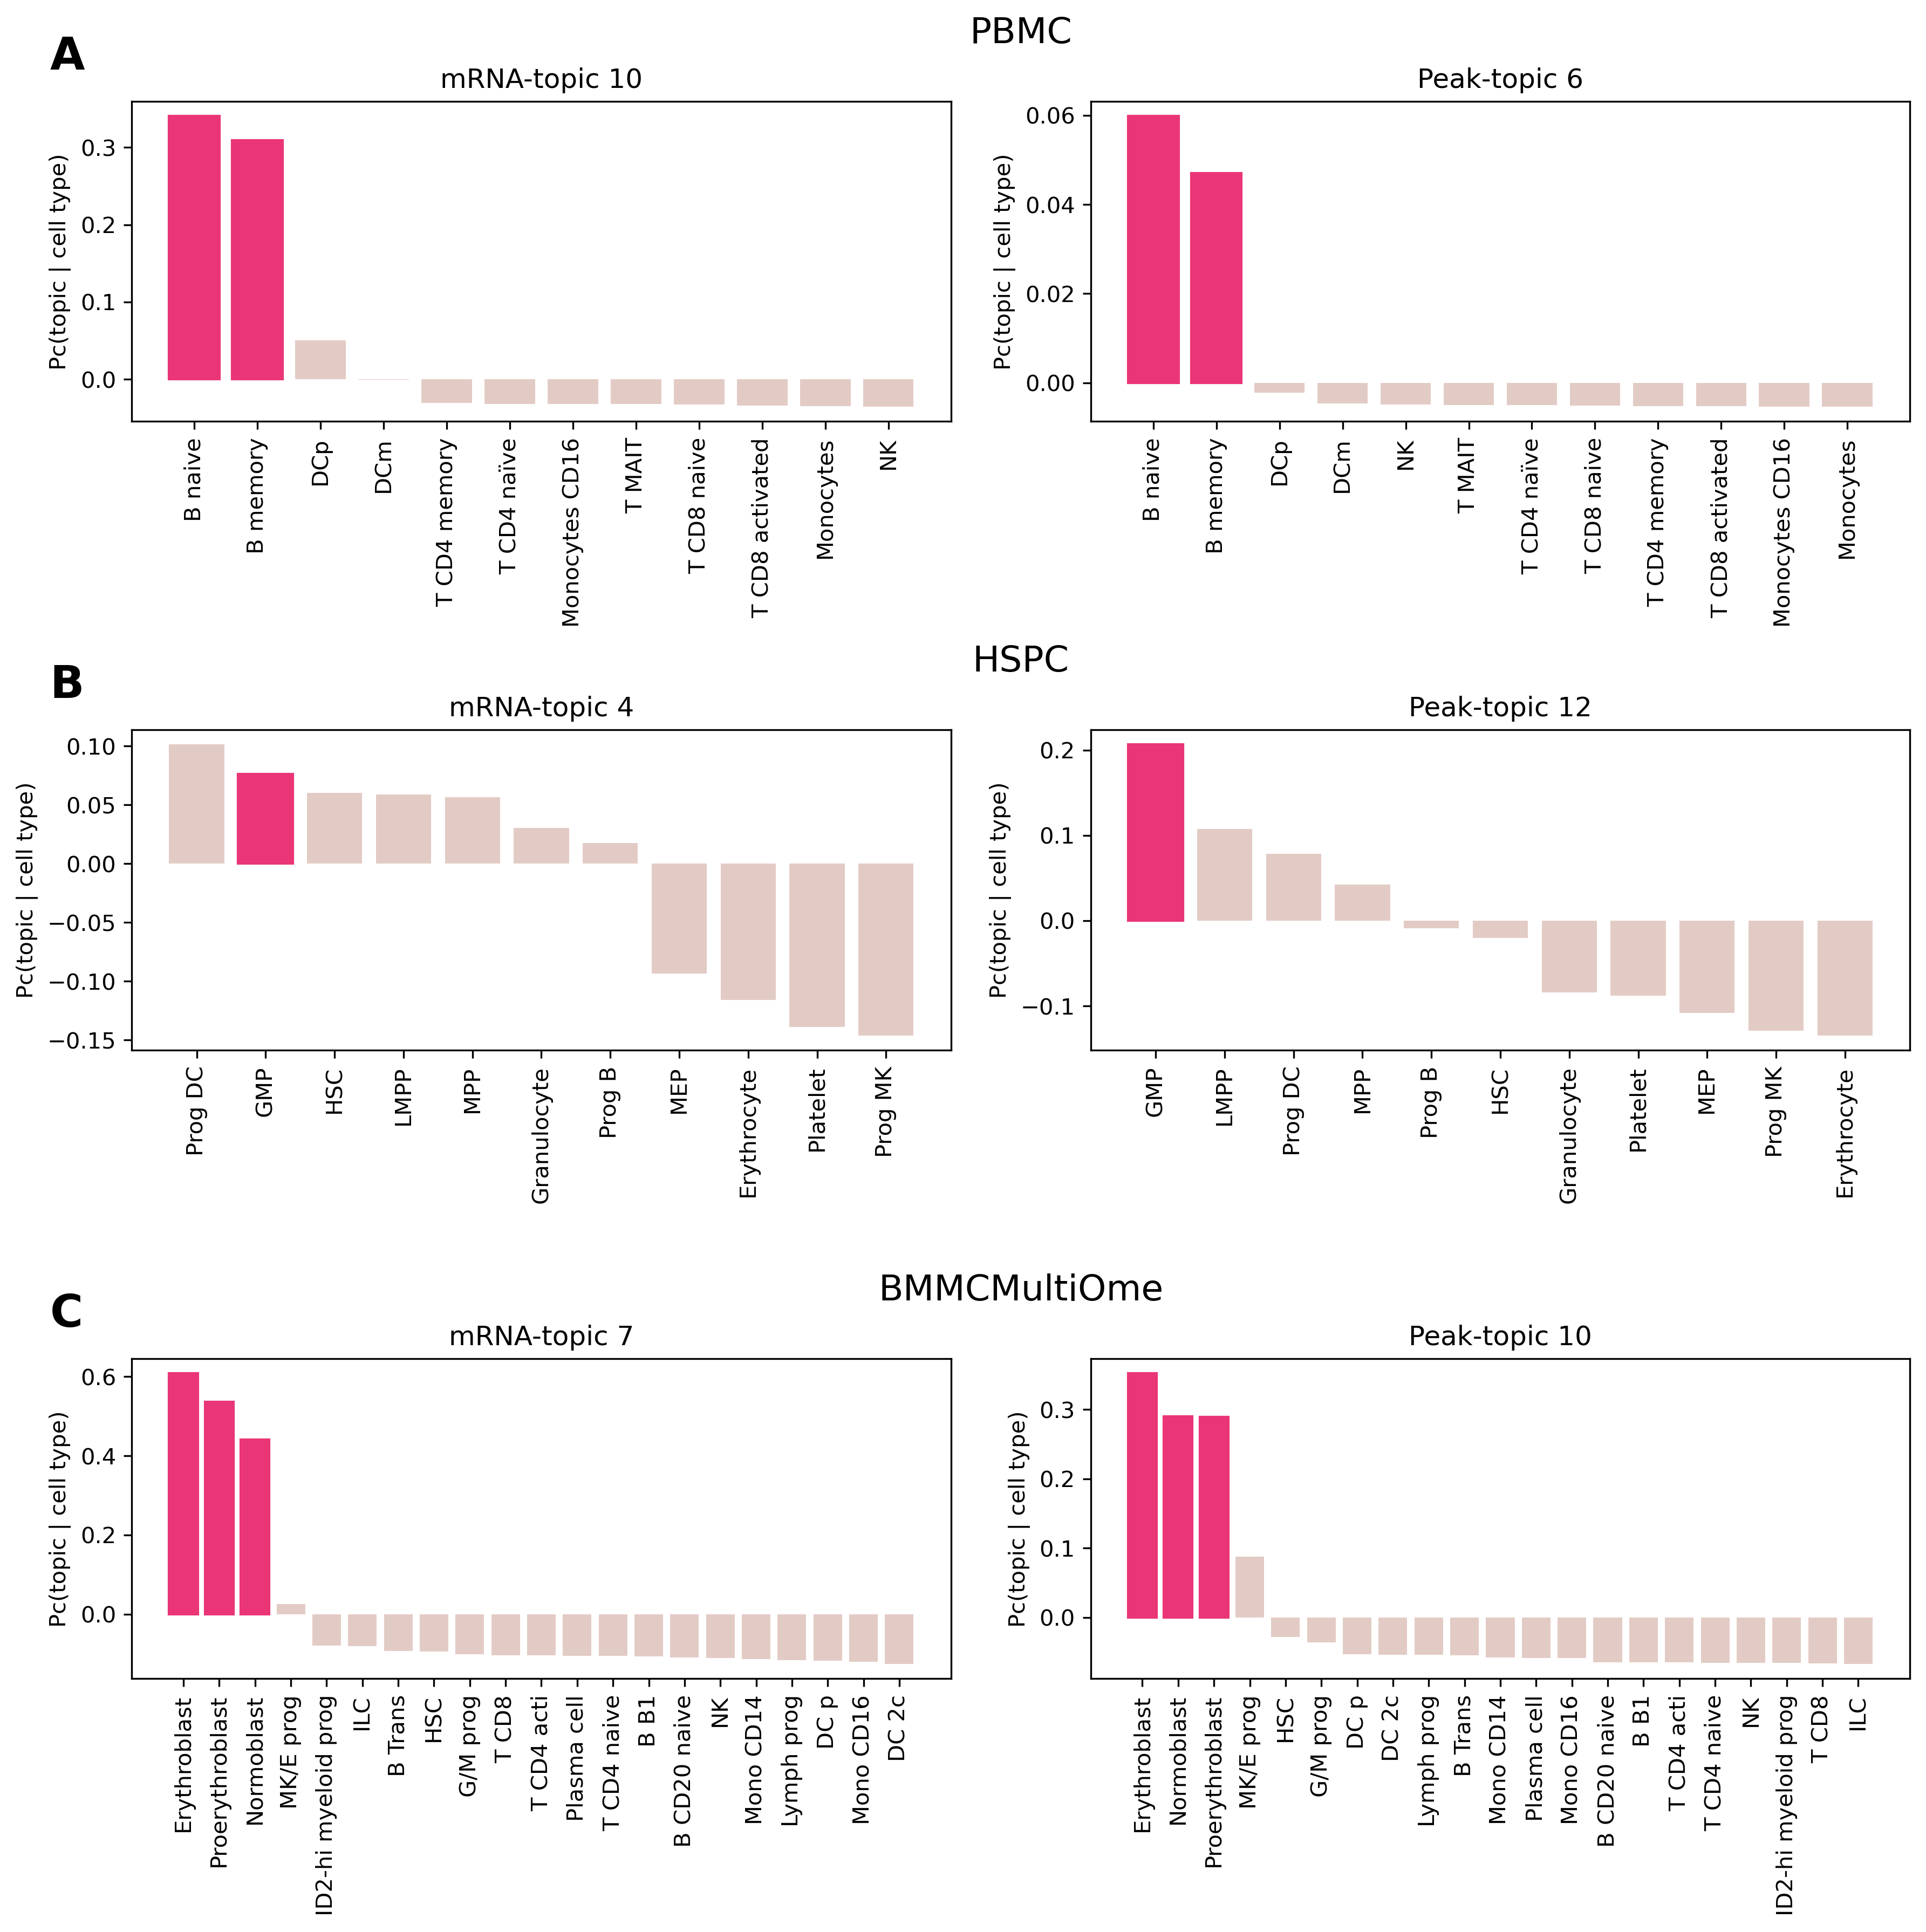

In [24]:
validation_df = pd.DataFrame([
    ["PBMC", ["B_memory","B_naive"], "Topic 10", "Topic 6", "PAX5", 22, 0, "Top on both", 156, "Datasets/PBMC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run22/Topic_6/knownResults.html"],
    ["HSPC", "GMP", "Topic 4", "Topic 12", "IRF8", 5, 2, "-", 44, 'Datasets/HSPC/bionSBM/Motifs/Peak_mRNA_lncRNA/Run5/Topic_12/knownResults.html'],
    ["BMMCMultiOme", ["Erythroblast","Normoblast","Proerythroblast"], "Topic 7", "Topic 10", "KLF1",19, 3, "Top in all 3", 10, 'Datasets/BMMCMultiOme/bionSBM/Motifs/Peak_mRNA_lncRNA/Run19/Topic_10/knownResults.html']],                              
    columns=["Dataset", "CellType", "mRNA-Topic", "Peak-topic", "Gene in mRNA-Topic", "Run", "Level", "Note", "Motif_Number", "Motif_HTML"])

# --------------------------------------------------
# Colors (already defined in your environment)
# --------------------------------------------------
dna_colors = {
    "A": colors_to_use[19],
    "C": colors_to_use[14],
    "G": colors_to_use[2],
    "T": colors_to_use[5]
}

BASE_COLOR = colors_to_use[11]
HIGHLIGHT_COLOR = colors_to_use[16]

# ---------------------------------------------
# Create single 3x3 figure
# ---------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=300)

for i, (_, row) in enumerate(validation_df.iterrows()):

    dataset = row["Dataset"]
    run = int(row["Run"])
    level = int(row["Level"])

    mrna_topic_num = int(re.search(r"\d+", row["mRNA-Topic"]).group())
    peak_topic_num = int(re.search(r"\d+", row["Peak-topic"]).group())

    cell_types_to_highlight = row["CellType"]
    
    if isinstance(cell_types_to_highlight, str):
        cell_types_to_highlight = [cell_types_to_highlight]
    # ---------------------------------------------
    # Load data (same logic as your function)
    # ---------------------------------------------
    metadata = pd.read_csv(
        f"Datasets/{dataset}/{dataset}_Metadata.tsv.gz",
        sep="\t",
        index_col=0
    )

    base_path = f"Datasets/{dataset}/bionSBM/bionSBM_Peak_mRNA_lncRNA/Runs/Run{run}"

    mRNA_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_mRNA_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    Peak_topics = pd.read_csv(
        os.path.join(base_path,
        f"bionSBM_Peak_mRNA_lncRNA_level_{level}_Peak_topics_documents.tsv.gz"),
        sep="\t",
        index_col=0
    )

    # Normalize topic naming
    mRNA_topics.columns = mRNA_topics.columns.str.replace("topics", "topic")
    Peak_topics.columns = Peak_topics.columns.str.replace("topics", "topic")

    # Align cells
    common_cells = (
        metadata.index
        .intersection(mRNA_topics.index)
        .intersection(Peak_topics.index)
    )

    metadata = metadata.loc[common_cells]
    mRNA_topics = mRNA_topics.loc[common_cells]
    Peak_topics = Peak_topics.loc[common_cells]

    # Center matrices (same as your logic)
    mRNA_centered = mRNA_topics - mRNA_topics.mean(axis=0)
    Peak_centered = Peak_topics - Peak_topics.mean(axis=0)

    # ---------------------------------------------
    # Compute Pc(topic | celltype) for ALL celltypes
    # ---------------------------------------------

    def compute_ct(doc_df):
        df = doc_df.copy()
        df["CellType"] = metadata["CellType"]
        return df.groupby("CellType").mean()

    mrna_ct = compute_ct(mRNA_centered)
    peak_ct = compute_ct(Peak_centered)

    # Validated topic names
    mrna_topic_name = [
        c for c in mRNA_topics.columns
        if c.endswith(f"_{mrna_topic_num}")
    ][0]

    peak_topic_name = [
        c for c in Peak_topics.columns
        if c.endswith(f"_{peak_topic_num}")
    ][0]

    # Values across ALL cell types
    mrna_values = mrna_ct[mrna_topic_name].sort_values(ascending=False)
    peak_values = peak_ct[peak_topic_name].sort_values(ascending=False)

    # ---------------------------------------------
    # Column 1 — mRNA
    # ---------------------------------------------
    ax_m = axes[i, 0]

    bars = ax_m.bar(range(len(mrna_values)), mrna_values.values, color=BASE_COLOR)

    # Highlight validated cell type
    for ct in cell_types_to_highlight:
        if ct in mrna_values.index:
            idx = list(mrna_values.index).index(ct)
            bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_m.set_xticks(range(len(mrna_values)))
    ax_m.set_xticklabels(mrna_values.index.str.replace("_", " "),rotation=90)
    mrna_topic_name=mrna_topic_name.replace("A_t","A-t").replace("_"," ")
    ax_m.set_title(mrna_topic_name)
    ax_m.set_ylabel("Pc(topic | cell type)")
    ax_m.text(-0.1, 1.1, string.ascii_uppercase[i], transform=ax_m.transAxes, fontsize=20, fontweight='bold')

    # ---------------------------------------------
    # Column 2 — Peak
    # ---------------------------------------------
    ax_p = axes[i, 1]

    bars = ax_p.bar(range(len(peak_values)), peak_values.values, color=BASE_COLOR)

    for ct in cell_types_to_highlight:
        if ct in peak_values.index:
            idx = list(peak_values.index).index(ct)
            bars[idx].set_color(HIGHLIGHT_COLOR)

    ax_p.set_xticks(range(len(peak_values)))
    ax_p.set_xticklabels(peak_values.index.str.replace("_", " "),rotation=90)
    peak_topic_name=peak_topic_name.replace("k_t","k-t").replace("_"," ")
    ax_p.set_title(peak_topic_name)
    ax_p.set_ylabel("Pc(topic | cell type)")


plt.tight_layout()

for i, (_, row) in enumerate(validation_df.iterrows()):
    # Force Matplotlib to update axis positions
    fig.canvas.draw()

    pos_left = axes[i, 0].get_position()
    pos_right = axes[i, 1].get_position()

    x_center = (pos_left.x1 + pos_right.x0) / 2
    y_center = pos_left.y1 + 0.035

    fig.text(x_center, y_center, row["Dataset"], ha="center", va="center", fontsize=16)


plt.savefig(f"Figures/bionSBM_SuppFig5.png", format="png", dpi=300, bbox_inches='tight')
plt.show()